In [20]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2

print("Libraries imported successfully!")

Libraries imported successfully!


In [28]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
DATASET_DIR = PROJECT_ROOT / "data" / "raw" / "NISTDB4"

print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATASET_DIR)
print("Dataset exists:", DATASET_DIR.exists())

Project root: c:\Users\johnm\fingerprint-feature-analyzer
Dataset path: c:\Users\johnm\fingerprint-feature-analyzer\data\raw\NISTDB4
Dataset exists: True


In [29]:
for path in sorted(DATASET_DIR.iterdir()):
    print(path.name, "→", "Directory" if path.is_dir() else "File")

class1_Arc → Directory
class2_Whorl → Directory
class3_Loop → Directory


In [30]:
IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff"
}

image_paths = [
    path
    for path in DATASET_DIR.rglob("*")
    if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
]

print("Total images found:", len(image_paths))

Total images found: 2401


In [35]:
records = []

for image_path in image_paths:
    relative_path = image_path.relative_to(DATASET_DIR)
    parts = relative_path.parts

    class_name = parts[0] if len(parts) > 0 else "Unknown"

    records.append({
        "filename": image_path.name,
        "path": str(image_path),
        "class": class_name,
        "extension": image_path.suffix.lower()
    })

df = pd.DataFrame(records)

df.head()

,filename,path,class,extension
0,class1_Arc_0001.png,c:\Users\johnm\fingerprint-feature-analyzer\da...,class1_Arc,.png
1,class1_Arc_0002.png,c:\Users\johnm\fingerprint-feature-analyzer\da...,class1_Arc,.png
2,class1_Arc_0003.png,c:\Users\johnm\fingerprint-feature-analyzer\da...,class1_Arc,.png
3,class1_Arc_0004.png,c:\Users\johnm\fingerprint-feature-analyzer\da...,class1_Arc,.png
4,class1_Arc_0005.png,c:\Users\johnm\fingerprint-feature-analyzer\da...,class1_Arc,.png


In [38]:
print(df.columns.tolist())

['filename', 'path', 'class', 'extension']


In [36]:
print("Total images:", len(df))

Total images: 2401


In [41]:
print(df["class"].value_counts())

class
class1_Arc      801
class3_Loop     801
class2_Whorl    799
Name: count, dtype: int64


In [39]:
print("NISTDB4 structure:\n")

for path in sorted(DATASET_DIR.iterdir()):
    if path.is_dir():
        print(f"\n📁 {path.name}")

        for child in sorted(path.iterdir()):
            if child.is_dir():
                print(f"   └── 📁 {child.name}")
            else:
                print(f"   └── 📄 {child.name}")

NISTDB4 structure:


📁 class1_Arc
   └── 📄 class1_Arc_0001.png
   └── 📄 class1_Arc_0002.png
   └── 📄 class1_Arc_0003.png
   └── 📄 class1_Arc_0004.png
   └── 📄 class1_Arc_0005.png
   └── 📄 class1_Arc_0006.png
   └── 📄 class1_Arc_0007.png
   └── 📄 class1_Arc_0008.png
   └── 📄 class1_Arc_0009.png
   └── 📄 class1_Arc_0010.png
   └── 📄 class1_Arc_0011.png
   └── 📄 class1_Arc_0012.png
   └── 📄 class1_Arc_0013.png
   └── 📄 class1_Arc_0014.png
   └── 📄 class1_Arc_0015.png
   └── 📄 class1_Arc_0016.png
   └── 📄 class1_Arc_0017.png
   └── 📄 class1_Arc_0018.png
   └── 📄 class1_Arc_0019.png
   └── 📄 class1_Arc_0020.png
   └── 📄 class1_Arc_0021.png
   └── 📄 class1_Arc_0022.png
   └── 📄 class1_Arc_0023.png
   └── 📄 class1_Arc_0024.png
   └── 📄 class1_Arc_0025.png
   └── 📄 class1_Arc_0026.png
   └── 📄 class1_Arc_0027.png
   └── 📄 class1_Arc_0028.png
   └── 📄 class1_Arc_0029.png
   └── 📄 class1_Arc_0030.png
   └── 📄 class1_Arc_0031.png
   └── 📄 class1_Arc_0032.png
   └── 📄 class1_Arc_0033.png
   └── 📄 

In [40]:
print("Dataset path:")
print(DATASET_DIR)

print("\nImmediate contents:")
for item in DATASET_DIR.iterdir():
    print(item)

Dataset path:
c:\Users\johnm\fingerprint-feature-analyzer\data\raw\NISTDB4

Immediate contents:
c:\Users\johnm\fingerprint-feature-analyzer\data\raw\NISTDB4\class1_Arc
c:\Users\johnm\fingerprint-feature-analyzer\data\raw\NISTDB4\class2_Whorl
c:\Users\johnm\fingerprint-feature-analyzer\data\raw\NISTDB4\class3_Loop


In [ ]:
print(df["extension"].value_counts())

extension
.png    2401
Name: count, dtype: int64


In [ ]:
sample_path = image_paths[0]

image = Image.open(sample_path)

print("File:", sample_path.name)
print("Format:", image.format)
print("Mode:", image.mode)
print("Size:", image.size)

File: class1_Arc_0001.png
Format: PNG
Mode: L
Size: (512, 512)


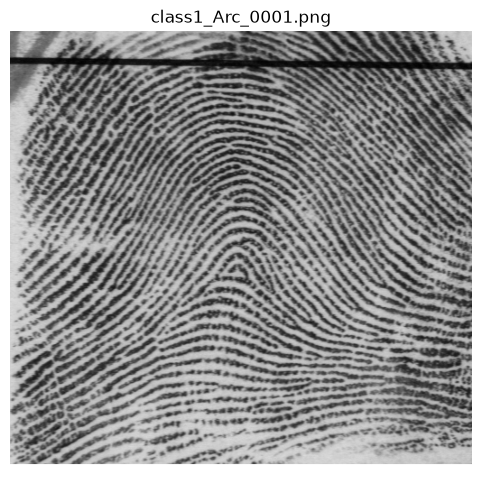

In [ ]:
plt.figure(figsize=(6, 6))

plt.imshow(image, cmap="gray")
plt.title(sample_path.name)
plt.axis("off")

plt.show()

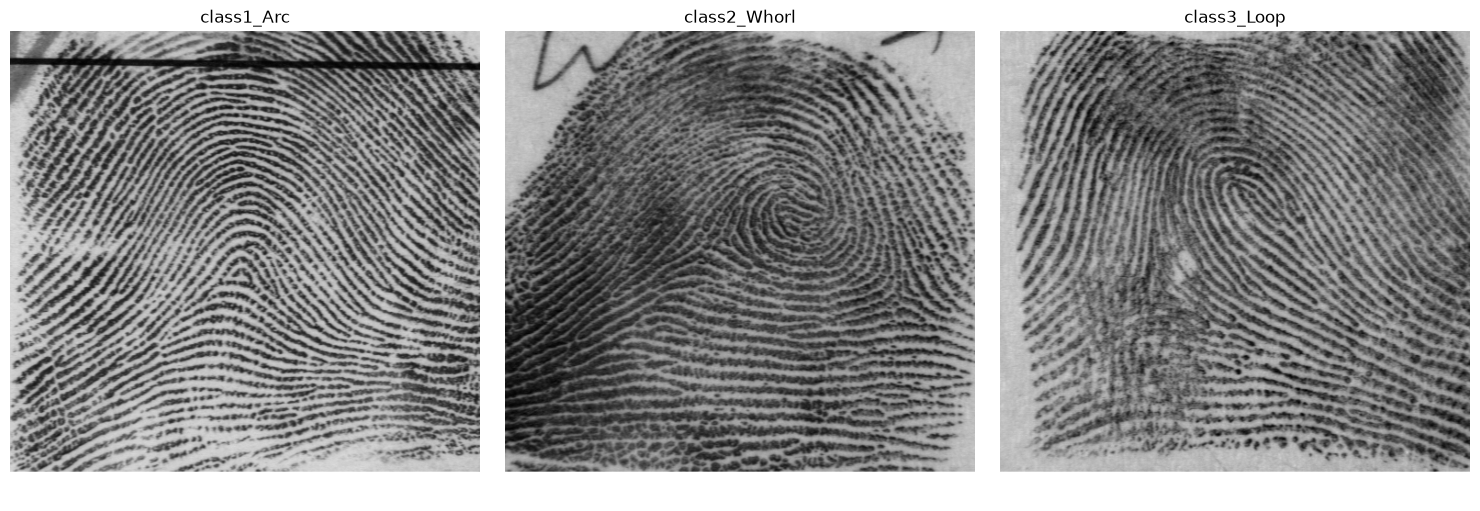

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, class_name in zip(
    axes,
    ["class1_Arc", "class2_Whorl", "class3_Loop"]
):
    
    class_images = df[df["class"] == class_name]

    image_path = Path(class_images.iloc[0]["path"])
    image = Image.open(image_path)

    ax.imshow(image, cmap="gray")
    ax.set_title(class_name)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
dimensions = []

for path in image_paths:
    try:
        with Image.open(path) as img:
            dimensions.append(img.size)
    except Exception as e:
        print("Could not read:", path, "|", e)

dimension_counts = pd.Series(dimensions).value_counts()

dimension_counts.head(20)

(512, 512)    2401
Name: count, dtype: int64

In [ ]:
#pixel statistics
sample_array = np.array(image)

print("Shape:", sample_array.shape)
print("Data type:", sample_array.dtype)
print("Minimum pixel value:", sample_array.min())
print("Maximum pixel value:", sample_array.max())
print("Mean pixel value:", sample_array.mean())
print("Standard deviation:", sample_array.std())

Shape: (512, 512)
Data type: uint8
Minimum pixel value: 36
Maximum pixel value: 255
Mean pixel value: 146.24209594726562
Standard deviation: 44.412274402237735


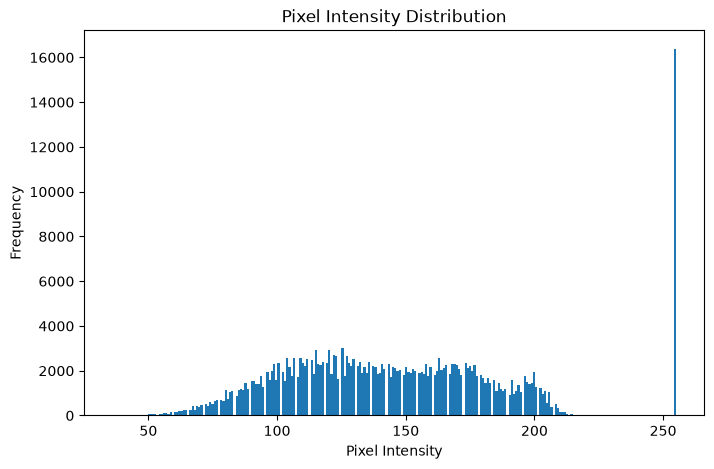

In [ ]:
# pixel intensity distribution
plt.figure(figsize=(8, 5))

plt.hist(
    sample_array.ravel(),
    bins=256
)

plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.show()

In [ ]:
#dataset summary
summary = {
    "Total images": len(df),
    "Number of classes": df["class"].nunique(),
    "Classes": df["class"].unique().tolist(),
    "Number of splits": df["split"].nunique(),
    "Splits": df["split"].unique().tolist(),
    "File types": df["extension"].unique().tolist(),
}

summary

{'Total images': 2401,
 'Number of classes': 3,
 'Classes': ['class1_Arc', 'class2_Whorl', 'class3_Loop'],
 'Number of splits': 2401,
 'Splits': ['class1_Arc_0001.png',
  'class1_Arc_0002.png',
  'class1_Arc_0003.png',
  'class1_Arc_0004.png',
  'class1_Arc_0005.png',
  'class1_Arc_0006.png',
  'class1_Arc_0007.png',
  'class1_Arc_0008.png',
  'class1_Arc_0009.png',
  'class1_Arc_0010.png',
  'class1_Arc_0011.png',
  'class1_Arc_0012.png',
  'class1_Arc_0013.png',
  'class1_Arc_0014.png',
  'class1_Arc_0015.png',
  'class1_Arc_0016.png',
  'class1_Arc_0017.png',
  'class1_Arc_0018.png',
  'class1_Arc_0019.png',
  'class1_Arc_0020.png',
  'class1_Arc_0021.png',
  'class1_Arc_0022.png',
  'class1_Arc_0023.png',
  'class1_Arc_0024.png',
  'class1_Arc_0025.png',
  'class1_Arc_0026.png',
  'class1_Arc_0027.png',
  'class1_Arc_0028.png',
  'class1_Arc_0029.png',
  'class1_Arc_0030.png',
  'class1_Arc_0031.png',
  'class1_Arc_0032.png',
  'class1_Arc_0033.png',
  'class1_Arc_0034.png',
  'cla